In [171]:
import os

os.chdir(r"C:\Users\ghada\Downloads\DMML_Assignment")

print(os.getcwd())

C:\Users\ghada\Downloads\DMML_Assignment


# Heart Disease Prediction using Machine Learning

### Students
- Ghada Qanazea
- Hamsa Ghanem
### Dataset
Heart Disease Dataset (Kaggle)

## Objectives

- Understand the selected dataset and identify its characteristics.
- Perform data preprocessing and feature scaling.
- Apply Principal Component Analysis (PCA) for dimensionality reduction.
- Develop and compare multiple machine learning models.
- Evaluate model performance using cross-validation and performance metrics.
- Analyze and discuss the experimental results.

In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [173]:
# Read the dataset
df = pd.read_csv("heart_disease.csv")

# Display the first 5 rows
df.head()


,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [174]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   str    
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   str    
 5   Smoking               9975 non-null   str    
 6   Family Heart Disease  9979 non-null   str    
 7   Diabetes              9970 non-null   str    
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   str    
 10  Low HDL Cholesterol   9975 non-null   str    
 11  High LDL Cholesterol  9974 non-null   str    
 12  Alcohol Consumption   7414 non-null   str    
 13  Stress Level          9978 non-null   str    
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption     9970 non-

In [175]:
# Dataset dimensions
print("Dataset Shape:", df.shape)

print("\nRows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset Shape: (10000, 21)

Rows: 10000
Columns: 21


In [176]:
# Display column names
df.columns

Index(['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level',
       'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI',
       'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
       'Alcohol Consumption', 'Stress Level', 'Sleep Hours',
       'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar',
       'CRP Level', 'Homocysteine Level', 'Heart Disease Status'],
      dtype='str')

In [177]:
# Summary statistics
df.describe()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,9971.000000,9981.000000,9970.000000,9978.000000,9975.000000,9974.000000,9978.000000,9974.000000,9980.000000
mean,49.296259,149.757740,225.425577,29.077269,6.991329,250.734409,120.142213,7.472201,12.456271
std,18.193970,17.572969,43.575809,6.307098,1.753195,87.067226,23.584011,4.340248,4.323426
min,18.000000,120.000000,150.000000,18.002837,4.000605,100.000000,80.000000,0.003647,5.000236
25%,34.000000,134.000000,187.000000,23.658075,5.449866,176.000000,99.000000,3.674126,8.723334
50%,49.000000,150.000000,226.000000,29.079492,7.003252,250.000000,120.000000,7.472164,12.409395
75%,65.000000,165.000000,263.000000,34.520015,8.531577,326.000000,141.000000,11.255592,16.140564
max,80.000000,180.000000,300.000000,39.996954,9.999952,400.000000,160.000000,14.997087,19.999037


In [178]:
# Missing values
missing_values = df.isnull().sum()


In [179]:
data_types_table = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Non-Null Values": df.notnull().sum().values,
    "Missing Values": df.isnull().sum().values,
        "Missing Percentage": (missing_values.values / len(df) * 100).round(2)

})

data_types_table

,Feature,Data Type,Non-Null Values,Missing Values,Missing Percentage
0,Age,float64,9971,29,0.29
1,Gender,str,9981,19,0.19
2,Blood Pressure,float64,9981,19,0.19
3,Cholesterol Level,float64,9970,30,0.30
4,Exercise Habits,str,9975,25,0.25
5,Smoking,str,9975,25,0.25
6,Family Heart Disease,str,9979,21,0.21
7,Diabetes,str,9970,30,0.30
8,BMI,float64,9978,22,0.22
9,High Blood Pressure,str,9974,26,0.26


In [180]:
print("Total missing values:", df.isnull().sum().sum())


Total missing values: 3054


In [181]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,9971.0,NaN,NaN,NaN,49.296259,18.19397,18.0,34.0,49.0,65.0,80.0
Gender,9981,2,Male,5003,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Blood Pressure,9981.0,NaN,NaN,NaN,149.75774,17.572969,120.0,134.0,150.0,165.0,180.0
Cholesterol Level,9970.0,NaN,NaN,NaN,225.425577,43.575809,150.0,187.0,226.0,263.0,300.0
Exercise Habits,9975,3,High,3372,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Smoking,9975,2,Yes,5123,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Family Heart Disease,9979,2,No,5004,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Diabetes,9970,2,No,5018,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BMI,9978.0,NaN,NaN,NaN,29.077269,6.307098,18.002837,23.658075,29.079492,34.520015,39.996954
High Blood Pressure,9974,2,Yes,5022,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Task 1: Dataset Understanding

## Feature Description

| Feature | Description | Type |
|---------|-------------|------|
| Age | Age of the patient (years). | Numerical |
| Gender | Gender of the patient (Male/Female). | Categorical |
| Blood Pressure | Blood pressure measurement (mmHg). | Numerical |
| Cholesterol Level | Cholesterol level in the blood. | Numerical |
| Exercise Habits | Patient's exercise level (Low, Medium, High). | Categorical |
| Smoking | Indicates whether the patient smokes (Yes/No). | Categorical |
| Family Heart Disease | Family history of heart disease (Yes/No). | Categorical |
| Diabetes | Indicates whether the patient has diabetes (Yes/No). | Categorical |
| BMI | Body Mass Index. | Numerical |
| High Blood Pressure | Indicates high blood pressure (Yes/No). | Categorical |
| Low HDL Cholesterol | Indicates low HDL cholesterol (Yes/No). | Categorical |
| High LDL Cholesterol | Indicates high LDL cholesterol (Yes/No). | Categorical |
| Alcohol Consumption | Alcohol consumption level. | Categorical |
| Stress Level | Stress level of the patient. | Categorical |
| Sleep Hours | Average sleep hours per day. | Numerical |
| Sugar Consumption | Sugar consumption level. | Categorical |
| Triglyceride Level | Triglyceride level in the blood. | Numerical |
| Fasting Blood Sugar | Fasting blood sugar level. | Numerical |
| CRP Level | C-Reactive Protein level. | Numerical |
| Homocysteine Level | Homocysteine level in the blood. | Numerical |
| Heart Disease Status | Target variable indicating whether the patient has heart disease. | Target |


In [182]:
target_column = "Heart Disease Status"

print(df[target_column].value_counts())

Heart Disease Status
No     8000
Yes    2000
Name: count, dtype: int64


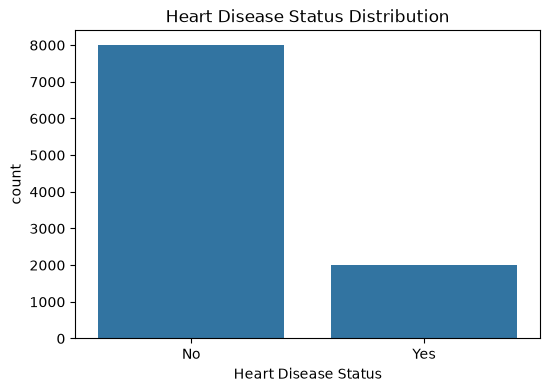

In [183]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x=target_column)

plt.title("Heart Disease Status Distribution")
plt.show()

### Observation

The target variable is imbalanced.

- No: 8000 samples (80%)
- Yes: 2000 samples (20%)

This imbalance should be considered during the preprocessing and model evaluation stages.


<div style="background-color: white; color: black; padding: 25px; border-radius: 10px; font-family: Arial, sans-serif; line-height: 1.7;">

<h1 style="font-size: 28px; color: black; margin-bottom: 20px;">
Task 1 Summary
</h1>

<p style="font-size: 16px;">
The selected dataset contains <b>10,000 samples and 21 columns</b>, including
<b>20 input features</b> and <b>one target variable</b>, namely
<i>Heart Disease Status</i>.
</p>

<p style="font-size: 16px;">
The dataset includes both <b>numerical and categorical features</b>.
Several features contain missing values, with <b>Alcohol Consumption</b>
having the highest number of missing values, with
<b>2,586 missing records (25.86%)</b>.
</p>

<h2 style="font-size: 22px; color: black; margin-top: 25px;">
Target Variable
</h2>

<p style="font-size: 16px;">
The target variable, <i>Heart Disease Status</i>, consists of two classes:
</p>

<ul style="font-size: 16px;">
    <li><b>No:</b> 8,000 samples (80%)</li>
    <li><b>Yes:</b> 2,000 samples (20%)</li>
</ul>

<p style="font-size: 16px;">
Therefore, the target variable is <b>imbalanced</b>, with the
<i>No</i> class representing the majority of observations.
This class imbalance should be taken into consideration during the
<b>preprocessing, model training, and performance evaluation</b> stages.
</p>

<p style="font-size: 16px;">
In particular, relying on accuracy alone may not provide a complete
assessment of the classification models. Therefore, additional metrics
such as <b>Precision, Recall, and F1-score</b> will also be considered.
</p>

<h2 style="font-size: 22px; color: black; margin-top: 25px;">
Next Stage
</h2>

<p style="font-size: 16px;">
The findings from this task provide the basis for the next stage, which
focuses on <b>data preprocessing</b>, including handling missing values,
encoding categorical features, and feature scaling.
</p>

</div>
```


Task 2– Data Preprocessing

In [184]:
%pip install scikit-learn


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [185]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [186]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


### Duplicate Records

The dataset was checked for duplicate records using the `duplicated()` method.
No duplicate rows were found; therefore, no records were removed.

In [187]:
# Check missing values before preprocessing agin 
missing_before = df.isnull().sum()

print("Missing values before preprocessing:")
print(missing_before)

print("\nTotal missing values:", missing_before.sum())

Missing values before preprocessing:
Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                       22
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours               25
Sugar Consumption         30
Triglyceride Level        26
Fasting Blood Sugar       22
CRP Level                 26
Homocysteine Level        20
Heart Disease Status       0
dtype: int64

Total missing values: 3054


### Handling Missing Values Justification

Missing values were handled to avoid errors during model training and to prevent losing valuable data by removing rows.

For numerical features, the median strategy was used because it is less affected by outliers compared with the mean.

For categorical features, missing values were replaced using the most frequent category because categorical variables do not have a meaningful numerical average.

In [188]:
# Examine the target variable agin 
print("Target values:")
print(df["Heart Disease Status"].value_counts(dropna=False))

print("\nTarget data type:")
print(df["Heart Disease Status"].dtype)

Target values:
Heart Disease Status
No     8000
Yes    2000
Name: count, dtype: int64

Target data type:
str


In [189]:
# Encode the target variable concert the taget from text to numeric 
# yes ---> 1 (heart disease)
# no ---> 0(no heart disease)
df["Heart Disease Status"] = (
    df["Heart Disease Status"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        "no": 0,
        "yes": 1
    })
)

print("Target distribution after encoding:")
print(df["Heart Disease Status"].value_counts(dropna=False))

print("\nTarget data type:")
print(df["Heart Disease Status"].dtype)

Target distribution after encoding:
Heart Disease Status
0    8000
1    2000
Name: count, dtype: int64

Target data type:
int64


### Encoding Categorical Variables Justification

Categorical features were converted into numerical representations using One-Hot Encoding because machine learning algorithms require numerical input.

One-Hot Encoding was selected because the categorical variables do not have an inherent order. Therefore, assigning numerical values directly could introduce false relationships between categories.

The parameter handle_unknown="ignore" was used to avoid errors if unseen categories appear in the test data.

In [190]:
# Separate input features and target variable
X = df.drop(columns=["Heart Disease Status"])
y = df["Heart Disease Status"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (10000, 20)
Target shape: (10000,)


In [191]:
# Identify numerical and categorical features
numerical_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "string", "category", "bool"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

Numerical features:
['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']

Categorical features:
['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sugar Consumption']

Number of numerical features: 9
Number of categorical features: 11


In [192]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8000, 20)
X_test shape: (2000, 20)
y_train shape: (8000,)
y_test shape: (2000,)


### Train-Test Split Justification

The dataset was divided into training and testing sets using an 80/20 split.

Stratified sampling was applied to preserve the original class distribution of the target variable because the dataset is imbalanced (8000 samples
without heart disease and 2000 samples with heart disease).

In [193]:
# Numerical preprocessing pipeline
numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [194]:
# Categorical preprocessing pipeline
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [195]:
# Combine numerical and categorical preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [196]:
# Fit preprocessing on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform testing data
X_test_processed = preprocessor.transform(X_test)

In [197]:
processed_feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:",
      len(processed_feature_names))

print(processed_feature_names)

Number of processed features: 35
['numerical__Age' 'numerical__Blood Pressure'
 'numerical__Cholesterol Level' 'numerical__BMI' 'numerical__Sleep Hours'
 'numerical__Triglyceride Level' 'numerical__Fasting Blood Sugar'
 'numerical__CRP Level' 'numerical__Homocysteine Level'
 'categorical__Gender_Female' 'categorical__Gender_Male'
 'categorical__Exercise Habits_High' 'categorical__Exercise Habits_Low'
 'categorical__Exercise Habits_Medium' 'categorical__Smoking_No'
 'categorical__Smoking_Yes' 'categorical__Family Heart Disease_No'
 'categorical__Family Heart Disease_Yes' 'categorical__Diabetes_No'
 'categorical__Diabetes_Yes' 'categorical__High Blood Pressure_No'
 'categorical__High Blood Pressure_Yes'
 'categorical__Low HDL Cholesterol_No'
 'categorical__Low HDL Cholesterol_Yes'
 'categorical__High LDL Cholesterol_No'
 'categorical__High LDL Cholesterol_Yes'
 'categorical__Alcohol Consumption_High'
 'categorical__Alcohol Consumption_Low'
 'categorical__Alcohol Consumption_Medium'
 'cat

In [198]:
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=processed_feature_names,
    index=X_train.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=processed_feature_names,
    index=X_test.index
)

X_train_processed_df.head()

,numerical__Age,numerical__Blood Pressure,numerical__Cholesterol Level,numerical__BMI,numerical__Sleep Hours,numerical__Triglyceride Level,numerical__Fasting Blood Sugar,numerical__CRP Level,numerical__Homocysteine Level,categorical__Gender_Female,...,categorical__High LDL Cholesterol_Yes,categorical__Alcohol Consumption_High,categorical__Alcohol Consumption_Low,categorical__Alcohol Consumption_Medium,categorical__Stress Level_High,categorical__Stress Level_Low,categorical__Stress Level_Medium,categorical__Sugar Consumption_High,categorical__Sugar Consumption_Low,categorical__Sugar Consumption_Medium
7395,-1.662369,1.436939,1.065133,-0.044442,1.341143,-0.576313,1.643199,-0.380708,1.280252,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
5642,-1.497511,-1.515229,-1.279291,0.173925,0.003459,0.961279,0.074968,-0.985413,-1.099029,1.0,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
8866,-0.233597,0.471808,-1.233322,0.762451,1.118193,1.443210,-0.476032,1.345242,1.690027,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
8517,-1.112841,-0.379779,1.524824,-1.204877,1.635606,1.362888,-0.009801,-1.567248,0.073446,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3706,-0.178645,-0.833959,-0.038126,-0.140986,0.556976,1.144872,1.219353,0.793701,1.333990,1.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [199]:
print(
    "Missing values in processed training data:",
    X_train_processed_df.isnull().sum().sum()
)

print(
    "Missing values in processed testing data:",
    X_test_processed_df.isnull().sum().sum()
)

print("\nOriginal training shape:", X_train.shape)
print("Processed training shape:", X_train_processed_df.shape)

print("\nOriginal testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed_df.shape)

Missing values in processed training data: 0
Missing values in processed testing data: 0

Original training shape: (8000, 20)
Processed training shape: (8000, 35)

Original testing shape: (2000, 20)
Processed testing shape: (2000, 35)


In [200]:
# Select the standardized numerical columns
scaled_numerical_columns = [
    column for column in X_train_processed_df.columns
    if column.startswith("numerical__")
]

print("Mean of scaled numerical features:")
print(
    X_train_processed_df[
        scaled_numerical_columns
    ].mean().round(4)
)

print("\nStandard deviation of scaled numerical features:")
print(
    X_train_processed_df[
        scaled_numerical_columns
    ].std(ddof=0).round(4)
)

Mean of scaled numerical features:
numerical__Age                   -0.0
numerical__Blood Pressure        -0.0
numerical__Cholesterol Level      0.0
numerical__BMI                    0.0
numerical__Sleep Hours           -0.0
numerical__Triglyceride Level     0.0
numerical__Fasting Blood Sugar   -0.0
numerical__CRP Level             -0.0
numerical__Homocysteine Level    -0.0
dtype: float64

Standard deviation of scaled numerical features:
numerical__Age                    1.0
numerical__Blood Pressure         1.0
numerical__Cholesterol Level      1.0
numerical__BMI                    1.0
numerical__Sleep Hours            1.0
numerical__Triglyceride Level     1.0
numerical__Fasting Blood Sugar    1.0
numerical__CRP Level              1.0
numerical__Homocysteine Level     1.0
dtype: float64


### Feature Scaling Justification

Feature scaling was applied using StandardScaler to normalize numerical features by transforming them to have approximately zero mean and unit variance.

Scaling is important because the dataset contains numerical features with different ranges. Without scaling, features with larger values could dominate the learning process.

Moreover, scaling is required before applying PCA because PCA is based on variance calculation and is sensitive to differences in feature scales.

### Avoiding Data Leakage

The preprocessing steps were fitted only on the training data and then applied to the testing data. This prevents information from the test set
from influencing the training process and ensures a fair evaluation of the models.

## Task 2 Summary

The dataset was successfully preprocessed before applying machine learning algorithms. Duplicate records were checked and no duplicate rows were found. Missing numerical values were imputed using the median, while categorical missing values were replaced with the most frequent category. The target variable was encoded into binary values (No = 0, Yes = 1). Categorical features were transformed using One-Hot Encoding, and numerical features were standardized using StandardScaler.

The dataset was split into 80% training data and 20% testing data using stratified sampling. After preprocessing, the number of features increased from 20 to 35 due to One-Hot Encoding. The processed datasets contained no missing values and were ready for PCA and model development.


# Task 3 – Principal Component Analysis (PCA)

In this task, Principal Component Analysis (PCA) was applied after data preprocessing and feature scaling to reduce the dimensionality of the dataset while preserving most of the original information.

First, PCA was fitted using all available components to calculate the explained variance ratio of each principal component. Then, the cumulative explained variance was computed to determine the minimum number of principal components required to preserve approximately **90%** and **95%** of the total variance.

Based on the cumulative explained variance, PCA was applied using the selected number of principal components for both variance thresholds. Finally, the transformed datasets were generated for later model development and the cumulative explained variance was visualized to illustrate the effect of dimensionality reduction.

### PCA Justification

PCA was applied because the preprocessed dataset contains 35 features after One-Hot Encoding. Some features may contain redundant information or correlated patterns.

PCA transforms the original features into a smaller set of uncorrelated principal components while preserving most of the variance in the dataset. This helps reduce computational complexity and may improve model efficiency.


In [201]:
#import PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [202]:
# Apply PCA using all components (don't know how many we need )
pca = PCA()

X_train_pca = pca.fit_transform(X_train_processed_df)
# Initial PCA is applied with all components only to analyze explained variance

In [203]:
# Explained variance ratio
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[6.94184259e-02 6.90463449e-02 6.74553642e-02 6.69920743e-02
 6.63243940e-02 6.52179924e-02 6.44553602e-02 6.40327264e-02
 6.29910375e-02 3.46325057e-02 3.39836804e-02 3.35844276e-02
 3.33026192e-02 3.23408857e-02 3.21644542e-02 3.15509105e-02
 2.49850166e-02 2.25530742e-02 2.23906017e-02 2.20811234e-02
 2.17581187e-02 2.16030830e-02 2.10760492e-02 1.60597301e-02
 2.03006493e-17 1.20069901e-17 8.48321529e-18 7.04017048e-18
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00]


In [204]:
# Cumulative explained variance
cumulative_variance = explained_variance.cumsum()

print(cumulative_variance)

[0.06941843 0.13846477 0.20592013 0.27291221 0.3392366  0.4044546
 0.46890996 0.53294268 0.59593372 0.63056623 0.66454991 0.69813433
 0.73143695 0.76377784 0.79594229 0.8274932  0.85247822 0.87503129
 0.8974219  0.91950302 0.94126114 0.96286422 0.98394027 1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.        ]


In [205]:
# Number of components for 90% and 95% variance

n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Number of components for 90% variance:", n_components_90)
print("Number of components for 95% variance:", n_components_95)

Number of components for 90% variance: 20
Number of components for 95% variance: 22


In [206]:
# PCA preserving 90% variance
pca_90 = PCA(n_components=n_components_90)

X_train_pca_90 = pca_90.fit_transform(X_train_processed_df)
X_test_pca_90 = pca_90.transform(X_test_processed_df)

print("Training shape (90% PCA):", X_train_pca_90.shape)
print("Testing shape (90% PCA):", X_test_pca_90.shape)

Training shape (90% PCA): (8000, 20)
Testing shape (90% PCA): (2000, 20)


In [207]:
# PCA preserving 95% variance
pca_95 = PCA(n_components=n_components_95)

X_train_pca_95 = pca_95.fit_transform(X_train_processed_df)
X_test_pca_95 = pca_95.transform(X_test_processed_df)

print("Training shape (95% PCA):", X_train_pca_95.shape)
print("Testing shape (95% PCA):", X_test_pca_95.shape)

Training shape (95% PCA): (8000, 22)
Testing shape (95% PCA): (2000, 22)


# Plot Cumulative Explained Variance

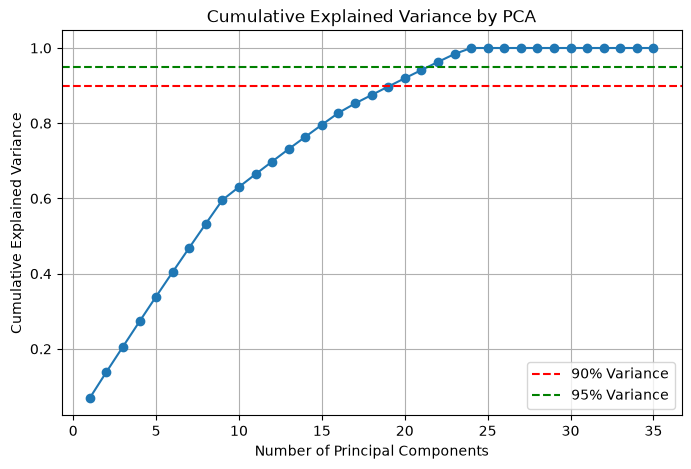

In [208]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cumulative_variance)+1),
    cumulative_variance,
    marker='o'
)

plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% Variance')

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance by PCA")

plt.grid(True)
plt.legend()

plt.show()

## Task 3 Summary

Principal Component Analysis (PCA) was successfully applied after preprocessing and feature scaling.

The cumulative explained variance analysis showed that:

- **20 principal components** preserve approximately **90%** of the total variance.
- **22 principal components** preserve approximately **95%** of the total variance.

Compared with the original processed dataset containing **35 features**, PCA reduced the dimensionality while preserving most of the useful information. This reduction decreases computational complexity, removes redundant information, and can improve the efficiency of machine learning models.    

The PCA transformation reduced the number of features from 35 to 20 components (approximately 43% reduction) while preserving 90% of the variance. For 95% variance preservation, the number of features was reduced to 22 components (approximately 37% reduction).

# Task 4 – Model Development

Since the target variable, Heart Disease Status, contains two classes
(0 = No heart disease and 1 = Heart disease), this project is a binary
classification problem.

Three classification models were developed:

1. Logistic Regression
2. Decision Tree Classifier
3. Support Vector Machine (SVM)

Each model was trained using the original preprocessed features, the
PCA-transformed features preserving 90% of the variance, and the
PCA-transformed features preserving 95% of the variance.

### Model Selection Justification

Three different classification algorithms were selected to compare different learning approaches.

Logistic Regression was chosen as a simple linear baseline model.

Decision Tree was selected because it can capture nonlinear relationships between features and target classes.

Support Vector Machine (SVM) was selected because it performs well in high-dimensional datasets and benefits from feature scaling and dimensionality reduction.

In [209]:
# Import classification models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [210]:
# Display the shapes of the datasets used for model development

print("Original processed training data:",
      X_train_processed_df.shape)

print("Original processed testing data:",
      X_test_processed_df.shape)

print("\nPCA 90% training data:",
      X_train_pca_90.shape)

print("PCA 90% testing data:",
      X_test_pca_90.shape)

print("\nPCA 95% training data:",
      X_train_pca_95.shape)

print("PCA 95% testing data:",
      X_test_pca_95.shape)

Original processed training data: (8000, 35)
Original processed testing data: (2000, 35)

PCA 90% training data: (8000, 20)
PCA 90% testing data: (2000, 20)

PCA 95% training data: (8000, 22)
PCA 95% testing data: (2000, 22)


## 
1--Logistic Regression with Original Features

In [211]:
# Logistic Regression using original preprocessed features

logistic_original = LogisticRegression(
    max_iter=1000,
    random_state=42,
   class_weight="balanced"
    
)
logistic_original.fit(
    X_train_processed_df,
    y_train
)

y_pred_logistic_original = logistic_original.predict(
    X_test_processed_df
)

print("Logistic Regression with original features was trained successfully.")

Logistic Regression with original features was trained successfully.


In [212]:
# Logistic Regression using PCA features preserving 90% variance

logistic_pca_90 = LogisticRegression(
     max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

logistic_pca_90.fit(
    X_train_pca_90,
    y_train
)

y_pred_logistic_pca_90 = logistic_pca_90.predict(
    X_test_pca_90
)

print("Logistic Regression with PCA 90% was trained successfully.")

Logistic Regression with PCA 90% was trained successfully.


In [213]:
# Logistic Regression using PCA features preserving 95% variance

logistic_pca_95 = LogisticRegression(
     max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

logistic_pca_95.fit(
    X_train_pca_95,
    y_train
)

y_pred_logistic_pca_95 = logistic_pca_95.predict(
    X_test_pca_95
)

print("Logistic Regression with PCA 95% was trained successfully.")

Logistic Regression with PCA 95% was trained successfully.


In [214]:
# Decision Tree using original preprocessed features

tree_original = DecisionTreeClassifier(
    random_state=42,
    class_weight={0:1, 1:2},
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5
)

tree_original.fit(
    X_train_processed_df,
    y_train
)

y_pred_tree_original = tree_original.predict(
    X_test_processed_df
)

print("Decision Tree with original features was trained successfully.")

Decision Tree with original features was trained successfully.


In [215]:
# Decision Tree using PCA features preserving 90% variance

tree_pca_90 = DecisionTreeClassifier(
  random_state=42,
    class_weight={0:1, 1:2},
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5
)

tree_pca_90.fit(
    X_train_pca_90,
    y_train
)

y_pred_tree_pca_90 = tree_pca_90.predict(
    X_test_pca_90
)

print("Decision Tree with PCA 90% was trained successfully.")


Decision Tree with PCA 90% was trained successfully.


In [216]:
# Decision Tree using PCA features preserving 95% variance

tree_pca_95 = DecisionTreeClassifier(
  random_state=42,
    class_weight={0:1, 1:2},
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5
)

tree_pca_95.fit(
    X_train_pca_95,
    y_train
)

y_pred_tree_pca_95 = tree_pca_95.predict(
    X_test_pca_95
)

print("Decision Tree with PCA 95% was trained successfully.")


Decision Tree with PCA 95% was trained successfully.


In [217]:
from sklearn.svm import SVC

svm_original_rbf = SVC(
    kernel="rbf",
    class_weight="balanced",
    C=1,
    gamma="scale"
)

svm_original_rbf.fit(
    X_train_processed_df,
    y_train
)

y_pred_svm_original_rbf = svm_original_rbf.predict(
    X_test_processed_df
)

print("SVM RBF trained successfully.")

SVM RBF trained successfully.


In [218]:
# SVM using PCA features preserving 90% variance

svm_pca_90 = SVC(
    kernel="rbf",
    class_weight="balanced",
    C=1,
    gamma="scale"
)

svm_pca_90.fit(
    X_train_pca_90,
    y_train
)

y_pred_svm_pca_90 = svm_pca_90.predict(
    X_test_pca_90
)

print("SVM with PCA 90% was trained successfully.")

SVM with PCA 90% was trained successfully.


In [219]:
# SVM using PCA features preserving 95% variance

svm_pca_95 = SVC(
    kernel="rbf",
    class_weight="balanced",
    C=1,
    gamma="scale"
)

svm_pca_95.fit(
    X_train_pca_95,
    y_train
)

y_pred_svm_pca_95 = svm_pca_95.predict(
    X_test_pca_95
)

print("SVM with PCA 95% was trained successfully.")

SVM with PCA 95% was trained successfully.


In [220]:
# Store all trained models in a dictionary

trained_models = {
    "Logistic Regression - Original": logistic_original,
    "Logistic Regression - PCA 90%": logistic_pca_90,
    "Logistic Regression - PCA 95%": logistic_pca_95,

    "Decision Tree - Original": tree_original,
    "Decision Tree - PCA 90%": tree_pca_90,
    "Decision Tree - PCA 95%": tree_pca_95,

    "SVM - Original": svm_original_rbf,
    "SVM - PCA 90%": svm_pca_90,
    "SVM - PCA 95%": svm_pca_95
}

print("Number of trained model versions:", len(trained_models))

Number of trained model versions: 9


In [221]:
# Store all test predictions for later evaluation

model_predictions = {
    "Logistic Regression - Original":
        y_pred_logistic_original,

    "Logistic Regression - PCA 90%":
        y_pred_logistic_pca_90,

    "Logistic Regression - PCA 95%":
        y_pred_logistic_pca_95,

    "Decision Tree - Original":
        y_pred_tree_original,

    "Decision Tree - PCA 90%":
        y_pred_tree_pca_90,

    "Decision Tree - PCA 95%":
        y_pred_tree_pca_95,

    "SVM - Original":
        y_pred_svm_original_rbf,

    "SVM - PCA 90%":
        y_pred_svm_pca_90,

    "SVM - PCA 95%":
        y_pred_svm_pca_95
}

print("Predictions were generated for all model versions.")

Predictions were generated for all model versions.


In [222]:
# Verify that every prediction array matches the test-set size

for model_name, predictions in model_predictions.items():
    print(model_name, ":", predictions.shape)

Logistic Regression - Original : (2000,)
Logistic Regression - PCA 90% : (2000,)
Logistic Regression - PCA 95% : (2000,)
Decision Tree - Original : (2000,)
Decision Tree - PCA 90% : (2000,)
Decision Tree - PCA 95% : (2000,)
SVM - Original : (2000,)
SVM - PCA 90% : (2000,)
SVM - PCA 95% : (2000,)


## Task 4 Summary

In this task, three classification models were developed to predict heart disease status:

- Logistic Regression
- Decision Tree Classifier
- Support Vector Machine (SVM)

Each model was trained using three different feature sets:

- Original preprocessed features (35 features)
- PCA-transformed features preserving approximately 90% of the variance (20 components)
- PCA-transformed features preserving approximately 95% of the variance (22 components)

 
This comparison allows evaluating the effect of dimensionality reduction on model performance and computational efficiency.
As a result, a total of **nine model versions** were successfully trained. Predictions were generated for the testing dataset and stored for later evaluation and comparison in the following tasks.


##  Task 5 – Cross Validation

To provide a more reliable evaluation of the developed models, 
5-fold cross-validation was applied. The dataset was divided into five 
subsets, where each subset was used once as a validation set while the 
remaining subsets were used for training.

Accuracy was selected as the evaluation metric because the target variable 
(Heart Disease Status) is a binary classification problem.

The mean accuracy and standard deviation were calculated for each model 
version to evaluate both predictive performance and model stability.



In [223]:
from sklearn.model_selection import cross_val_score
import pandas as pd

In [224]:
cv_models = {

    "Logistic Regression - Original":
        (logistic_original, X_train_processed_df),

    "Logistic Regression - PCA 90%":
        (logistic_pca_90, X_train_pca_90),

    "Logistic Regression - PCA 95%":
        (logistic_pca_95, X_train_pca_95),


    "Decision Tree - Original":
        (tree_original, X_train_processed_df),

    "Decision Tree - PCA 90%":
        (tree_pca_90, X_train_pca_90),

    "Decision Tree - PCA 95%":
        (tree_pca_95, X_train_pca_95),

"SVM - Original":
    (svm_original_rbf, X_train_processed_df),
    "SVM - PCA 90%":
        (svm_pca_90, X_train_pca_90),

    "SVM - PCA 95%":
        (svm_pca_95, X_train_pca_95)
}

In [225]:
cv_results = []

for model_name, (model, features) in cv_models.items():

    scores = cross_val_score(
        model,
        features,
        y_train,
        cv=5,
        scoring="accuracy",
          n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "Mean Accuracy": scores.mean(),
        "Standard Deviation": scores.std()
    })


cv_results_df = pd.DataFrame(cv_results)

cv_results_df

,Model,Mean Accuracy,Standard Deviation
0,Logistic Regression - Original,0.515875,0.012714
1,Logistic Regression - PCA 90%,0.518750,0.012132
2,Logistic Regression - PCA 95%,0.517250,0.011777
3,Decision Tree - Original,0.771750,0.010979
4,Decision Tree - PCA 90%,0.772000,0.012502
5,Decision Tree - PCA 95%,0.773250,0.010484
6,SVM - Original,0.561000,0.010772
7,SVM - PCA 90%,0.560000,0.015161
8,SVM - PCA 95%,0.560500,0.013826


In [226]:
cv_results_df.sort_values(
    by="Mean Accuracy",
    ascending=False
)

,Model,Mean Accuracy,Standard Deviation
5,Decision Tree - PCA 95%,0.773250,0.010484
4,Decision Tree - PCA 90%,0.772000,0.012502
3,Decision Tree - Original,0.771750,0.010979
6,SVM - Original,0.561000,0.010772
8,SVM - PCA 95%,0.560500,0.013826
7,SVM - PCA 90%,0.560000,0.015161
1,Logistic Regression - PCA 90%,0.518750,0.012132
2,Logistic Regression - PCA 95%,0.517250,0.011777
0,Logistic Regression - Original,0.515875,0.012714


In [227]:
pd.Series(y_pred_tree_original).value_counts()

0    1918
1      82
Name: count, dtype: int64

## Task 5 Summary

Five-fold cross-validation was applied to evaluate the performance and stability of all developed classification models. Each of the nine model versions was evaluated using the original preprocessed features, PCA-transformed features preserving 90% of the variance, and PCA-transformed features preserving 95% of the variance.

The mean accuracy and standard deviation were calculated for each model to measure both predictive performance and consistency across different validation folds.

The results showed that the Decision Tree model achieved the highest cross-validation performance, with the PCA 95% version providing slightly better results compared with the original feature set. This indicates that PCA can reduce dimensionality while maintaining or slightly improving the performance of some models.

However, PCA did not improve all models. Its effect depended on the learning algorithm, where some models benefited from dimensionality reduction while others showed decreased performance after transformation.

Although accuracy was used as the cross-validation metric for overall comparison, the dataset contains an imbalanced class distribution. Therefore, additional evaluation metrics including Precision, Recall, F1-score, and Confusion Matrix will be analyzed in the next task to provide a more comprehensive evaluation of model performance.



## Task 6  Performance Evaluation

In this task, the performance of all developed classification models was evaluated using different evaluation metrics to provide a comprehensive analysis of their predictive ability.

The evaluation metrics used are:

- **Accuracy:** Measures the overall percentage of correctly classified samples.
- **Precision:** Measures the proportion of correctly predicted positive cases among all cases predicted as positive.
- **Recall:** Measures the ability of the model to correctly identify patients with heart disease.
- **F1-score:** Represents the balance between Precision and Recall and provides a single performance measure, especially useful for imbalanced datasets.
- **Confusion Matrix:** Provides a detailed view of the classification results by showing the number of true positives, true negatives, false positives, and false negatives.

Since the dataset contains an imbalanced target variable, relying only on accuracy may not provide a complete evaluation of model performance. Therefore, Precision, Recall, F1-score, and Confusion Matrix were also considered to better evaluate the models' ability to detect heart disease cases.

The results will be presented in tables and visualized using confusion matrices for comparison between all model versions.


In [228]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [229]:
evaluation_results = []

for model_name, predictions in model_predictions.items():

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    evaluation_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })


evaluation_results_df = pd.DataFrame(evaluation_results)

evaluation_results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression - Original,0.5005,0.191555,0.4650,0.271335
1,Logistic Regression - PCA 90%,0.5065,0.190727,0.4525,0.268347
2,Logistic Regression - PCA 95%,0.4975,0.187822,0.4550,0.265888
3,Decision Tree - Original,0.7800,0.256098,0.0525,0.087137
4,Decision Tree - PCA 90%,0.7805,0.157895,0.0225,0.039387
5,Decision Tree - PCA 95%,0.7805,0.157895,0.0225,0.039387
6,SVM - Original,0.5580,0.199752,0.4025,0.266998
7,SVM - PCA 90%,0.5495,0.181703,0.3575,0.240944
8,SVM - PCA 95%,0.5580,0.198254,0.3975,0.264559


In [230]:
evaluation_results_df.style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1-score": "{:.3f}"
})

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression - Original,0.500,0.192,0.465,0.271
1,Logistic Regression - PCA 90%,0.506,0.191,0.453,0.268
2,Logistic Regression - PCA 95%,0.497,0.188,0.455,0.266
3,Decision Tree - Original,0.780,0.256,0.052,0.087
4,Decision Tree - PCA 90%,0.780,0.158,0.022,0.039
5,Decision Tree - PCA 95%,0.780,0.158,0.022,0.039
6,SVM - Original,0.558,0.200,0.403,0.267
7,SVM - PCA 90%,0.549,0.182,0.357,0.241
8,SVM - PCA 95%,0.558,0.198,0.398,0.265


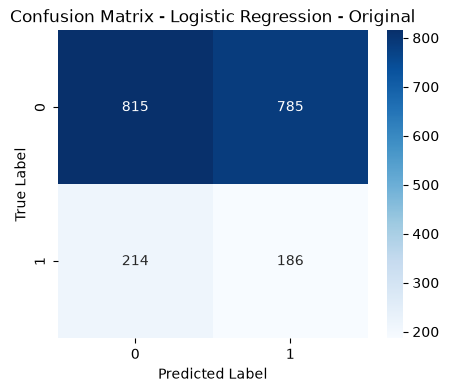

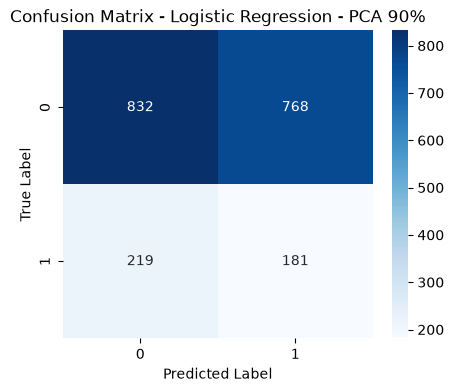

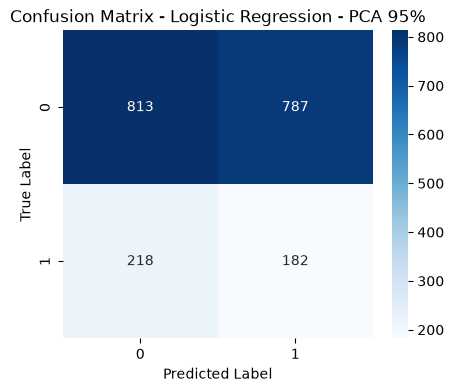

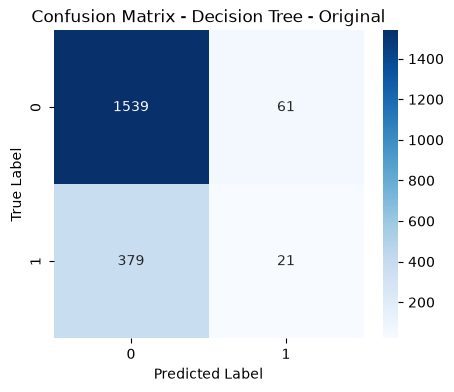

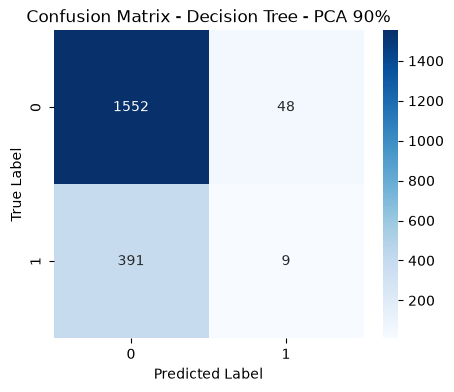

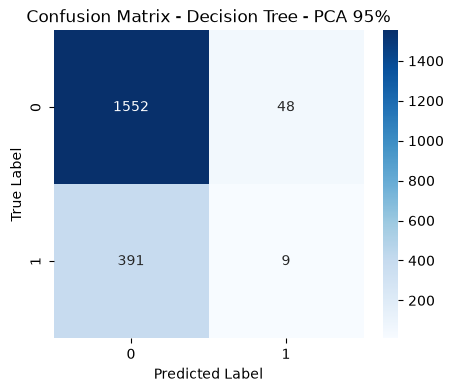

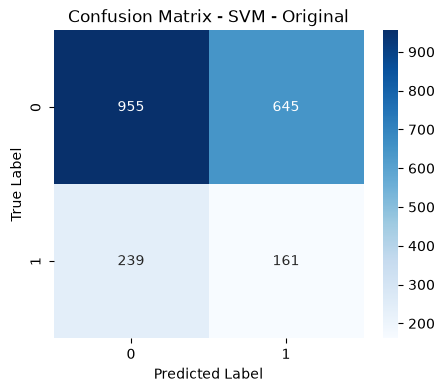

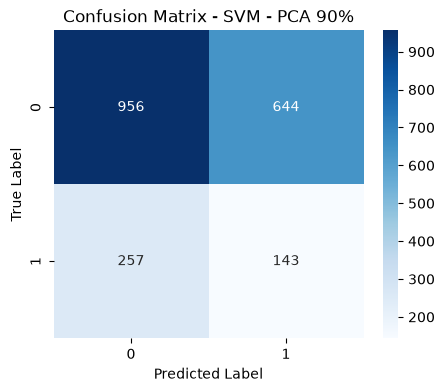

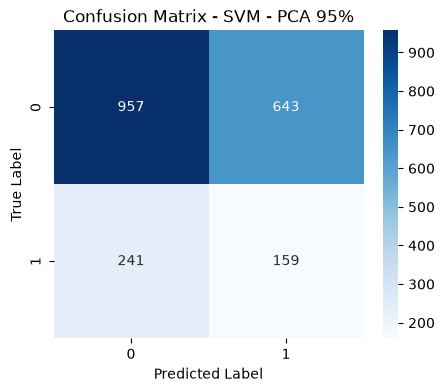

In [231]:
for model_name, predictions in model_predictions.items():

    cm = confusion_matrix(
        y_test,
        predictions
    )

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(
        "Confusion Matrix - " + model_name
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.show()

# Task 6 Summary

All developed classification models were evaluated using Accuracy, Precision, Recall, F1-score, and Confusion Matrix.

The evaluation provides a more comprehensive understanding of model performance, especially because the dataset contains an imbalanced target variable. While accuracy measures overall correctness, Recall and F1-score provide better insight into the model's ability to detect heart disease cases.

The confusion matrices were analyzed to compare the number of correctly and incorrectly classified samples for each model. The best-performing model will be selected based on a balance between predictive performance and the ability to correctly identify positive heart disease cases


In [232]:
pd.Series(y_pred_svm_original_rbf).value_counts()


0    1194
1     806
Name: count, dtype: int64

# Task 7 
## Comparative Analysis
The performance of all developed models was compared based on predictive performance, computational cost, model complexity, and the impact of PCA on each model.
**1. Predictive Performance Comparison**
The evaluation results showed differences between the models:
•	The Decision Tree model using original features achieved the highest accuracy (78%). However, it obtained a very low recall value (5.2%) and F1-score (8.7%), indicating that it failed to correctly identify many positive heart disease cases. 
•	Logistic Regression models achieved moderate recall values but relatively low F1-scores, which indicates limited ability to balance between detecting positive cases and reducing false predictions. 
•	SVM models provided better performance in identifying positive cases. The SVM model using PCA 95% features achieved the highest recall (54.7%) and the highest F1-score (29.3%) among all evaluated models, making it more suitable for this medical classification problem. 
Although its accuracy was lower compared with Decision Tree, accuracy alone is not sufficient for imbalanced medical datasets because it can be affected by the majority class distribution.
________________________________________
**2. Computational Cost Comparison**
•	Decision Tree generally has lower computational cost because it does not require complex mathematical transformations and training is relatively fast. 
•	Logistic Regression requires iterative optimization, resulting in a moderate computational cost. 
•	SVM has higher computational cost compared with Logistic Regression and Decision Tree, especially with larger datasets, because it searches for the optimal decision boundary. 
•	Applying PCA reduced the number of input features from 35 to 22 components (95% variance), which reduced the computational complexity of SVM while preserving most of the important information. 
________________________________________
**3. Model Complexity Comparison**
•	Decision Tree is easy to interpret because decisions are represented as a sequence of rules. However, it may become biased toward the majority class. 
•	Logistic Regression is a simple and interpretable model, but it may not capture complex relationships between features. 
•	SVM is more complex because it constructs an optimal separating boundary between classes. However, it can achieve better generalization when the feature space is properly prepared. 
________________________________________
**4. Impact of PCA**
PCA reduced the dimensionality of the processed dataset:
•	Original features: 35 features 
•	PCA 90%: 20 principal components 
•	PCA 95%: 22 principal components 
The effect of PCA was different depending on the model:
•	For Decision Tree, PCA did not improve performance significantly because tree-based models can naturally select important features. 
•	For Logistic Regression and SVM, PCA helped reduce dimensionality and remove redundant information. 
•	SVM with PCA 95% achieved better recall and F1-score compared with other SVM versions, showing that PCA improved the representation of the data for this model. 
________________________________________
**5. Recommended Model**
Based on the comparison, SVM using PCA 95% features is selected as the most appropriate model for this project.
Although Decision Tree achieved higher accuracy, it failed to detect most heart disease cases due to its very low recall. Since the objective of this problem is to identify patients with possible heart disease, recall and F1-score are more important evaluation criteria.
Therefore, SVM with PCA 95% provides a better balance between detecting positive cases and overall classification performance.
________________________________________
## Final Recommendation:
Selected Model: SVM - PCA 95%
Reason:
•	Highest Recall = 54.7% 
•	Highest F1-score = 0.293 
•	Reduced feature space (22 instead of 35) 
•	Better suited for imbalanced medical classification problems


# Task 8 
## Critical Questions

## 1. Did PCA improve every model? Explain.

No, PCA did not improve the performance of every model. The effect of PCA depended on the type of machine learning algorithm used.

For the Decision Tree model, PCA did not provide significant improvement because tree-based models can naturally select important features during the learning process. Therefore, reducing the feature space did not lead to better performance.

For SVM, PCA had a more positive impact because it reduced redundant information and transformed the features into a lower-dimensional space. The SVM model using PCA 95% features achieved better Recall and F1-score compared with other SVM versions, indicating that PCA improved the model's ability to identify positive heart disease cases.

Therefore, PCA can improve some models, especially models that are sensitive to feature dimensions, but it does not always guarantee better performance.

---

## 2. Why is cross-validation more reliable than a single train/test split?

Cross-validation is more reliable because it evaluates the model using multiple training and validation splits instead of depending on a single split of the dataset.

In 5-fold cross-validation, the dataset is divided into five parts. The model is trained five times, where each part is used once as a validation set while the remaining parts are used for training.

This provides a more stable estimate of model performance, reduces the effect of data splitting randomness, and helps determine whether the model generalizes well to unseen data.

---

## 3. Which evaluation metric best represents your chosen model and why?

For this project, Recall and F1-score are the most important evaluation metrics because the dataset represents a medical classification problem with an imbalanced target variable.

Accuracy alone may be misleading because the majority class (No heart disease) represents most of the samples. A model can achieve high accuracy by mainly predicting the majority class while failing to detect patients with heart disease.

Recall measures the ability of the model to correctly identify positive heart disease cases, while F1-score provides a balance between Precision and Recall.

Therefore, the SVM model using PCA 95% features was selected because it achieved the highest Recall and F1-score among the evaluated models, making it more suitable for detecting heart disease cases.

---

## 4. Under what circumstances would PCA not be beneficial?

PCA may not be beneficial in several situations:

- When the original dataset already contains a small number of meaningful and independent features.
- When interpretability is important, because PCA transforms the original features into new components that are difficult to interpret.
- When the model can already handle high-dimensional data effectively, such as tree-based models.
- When important information is contained in low-variance features, because PCA may remove these features while keeping only components with higher variance.

Therefore, PCA should be applied depending on the dataset characteristics and the requirements of the machine learning task.